In [ ]:
import sys
sys.path.append('../')

import numpy as np
import scipy.sparse as ssp
import matplotlib.pyplot as plt
import qutip as qt
import scqubits as scq
from matplotlib.colors import LogNorm
from tqdm import tqdm
from qutip.qip.operations import rz, cz_gate
import cmath
from sympy import symbols
import utils_2Q_gate_zp as ut
import scipy as sp
import pandas as pd
import itertools

cnot = pd.read_csv('data/data_cnot_fidelity_3ncut.txt')
# df = pd.DataFrame(p, columns=['tg', 'drive_amp_1', 'drive_amp_2', 'detune_1',
#                                    'detune_2', 'f_200_select', 'f_1000_False',  ])
# df.to_csv('data/data_cnot_fidelity_3ncut.txt', sep=',', index=False, header=True)

tg_list = [50, 120, 190, 260, 330]
msteps = [1e-5, 3e-5, 1e-4, 3e-4, 1e-3]



In [ ]:
n_truc_list = [250, 350, 450, 550, 650, 750, 850, 950, 1050, 1150, 1250, 1350, 1450, 1550, 1650, 1750, 1850, 1950]

fidelity_list = np.array([
[-0.5692765711431094, -1.3980468816094416, -2.0455663858321786, -2.3096608421083418, -2.5252755957015425] ,
[-0.6770840612415304, -1.440259015792347, -2.100972956713666, -2.366976423251946, -2.580095245498633] ,
[-0.6865283395275958, -1.4440226833212475, -2.0670495151969446, -2.3308787296509617, -2.544199697869001] ,
[-0.5405147276039688, -1.3790275356922888, -2.5665894327692076, -3.1180474826333655, -3.430589573521751] ,
[-0.5213659888171006, -1.3456023337996452, -2.529075060933569, -3.1207291622294724, -3.452694374756259] ,
[-0.5262247955601103, -1.3504420937140265, -2.5331505945645008, -3.12213434143799, -3.4531533178727036] ,
[-0.5330867541401818, -1.3507930746211274, -2.5333431649980764, -3.121984471668593, -3.4527228419981273] ,
[-0.5035099263878757, -1.353861812047504, -2.538242231025034, -3.1230067750913113, -3.4528962545756823] ,
[-0.5037126064479577, -1.3529750242452128, -2.5382785804736074, -3.1231018434005056, -3.452935112101526] ,
[-0.4878139616321936, -1.3220694820998928, -2.5288765155823505, -3.1218766834857012, -3.452212134753265] ,
[-0.48735979868157053, -1.321637475380225, -2.527944364913111, -3.1217422536387245, -3.45218405740171] ,
[-0.485359592585618, -1.315353898349901, -2.5211779826409066, -3.1213898174685264, -3.452021209357267] ,
[-0.4984404945436228, -1.3152951208502752, -2.521215819576612, -3.120968696068634, -3.451682867402915] ,
[-0.4981941560650106, -1.315492395726841, -2.521236007318802, -3.1209287904805585, -3.4516903587210166] ,
[-0.49801016634555034, -1.311932074351781, -2.5162266678967815, -3.1205396702962833, -3.4514447766912837] ,
[-0.5000919146237648, -1.310036061066369, -2.5103154456855385, -3.1203060515480496, -3.4512959385334474] ,
[-0.499212635809983, -1.2568977862494388, -2.1431923084680053, -2.814213001457443, -3.3895234203970444] ,
[-0.503447155370532, -1.2692765513433204, -2.0532722206900065, -2.801637641226889, -3.3880678785221607] ,
])

n_truc_list = [200, 300, 400, 500, 600, 700, 800, 900, 1000, 1100, 1200, 1300, 1400, 1500, 1600, 1700, 1800, 1900, 2000]

fidelity_list = np.array([
[-0.5380398274168483, -1.3965438397266048, -2.0678396225866527, -2.3241868313602927, -2.536063181719862] ,
[-0.6620480438499335, -1.4308087642885636, -2.1135574687040437, -2.385425767983634, -2.6007947750338345] ,
[-0.6865974461448204, -1.4438058369003017, -2.071510259035406, -2.3365348832233357, -2.550284920623823] ,
[-0.5684386619613143, -1.4026625062788087, -2.1023474999357403, -2.377010670247891, -2.591656492544061] ,
[-0.5277426602479052, -1.361162879742342, -2.552932158461214, -3.1220866633810536, -3.441464820679873] ,
[-0.5254936519263165, -1.3484678843980635, -2.531561662124169, -3.121711456670111, -3.4530756836084326] ,
[-0.5287847621904233, -1.349719098978597, -2.5322390983627714, -3.121691600649167, -3.4529184554154666] ,
[-0.534426865059239, -1.350824680913241, -2.5333702817229145, -3.1218316165927584, -3.4525695480445093] ,
[-0.5022777540062924, -1.3528388418901416, -2.5381622624862725, -3.122983958030158, -3.4528778297464715] ,
[-0.4955827885766936, -1.3394080782000781, -2.5387248322863862, -3.1220359556965116, -3.4523507720182134] ,
[-0.48760591261695213, -1.3221620029710455, -2.5287019036633405, -3.121934905217436, -3.4522614943040515] ,
[-0.4853947971963811, -1.3153267075653665, -2.5208513858089887, -3.121379813206692, -3.4519990088812538] ,
[-0.4860314399146909, -1.3148829555722625, -2.520122704533074, -3.120812618828495, -3.4516949078973345] ,
[-0.4983178921216474, -1.3154470965314722, -2.5212634192411136, -3.1209670423637936, -3.4517028292829135] ,
[-0.4978754812669829, -1.3139762106076658, -2.519111836700185, -3.1209024956774227, -3.4516791336581503] ,
[-0.4981142925935999, -1.3119356770618473, -2.5161968321266697, -3.1205224433170393, -3.451445091781631] ,
[-0.49793914084128565, -1.2543296251568452, -2.1350606807667982, -2.7955511784565665, -3.394542114805603] ,
[-0.4986846079145888, -1.2567193420380511, -2.141863383668857, -2.8051451320360843, -3.3890168713373194] ,
[-0.5006685769536475, -1.2679685089425814, -2.060829660086039, -2.798949491888254, -3.3881154987770072] ,
])

In [ ]:
import numpy as np

# 假设已经定义：
# n_truc_list1, fidelity_list1
# n_truc_list2, fidelity_list2

# Step 1: column stack
data1 = np.column_stack(fidelity_list1)
data2 = np.column_stack(fidelity_list2)

# Step 2: row stack
combined_data = np.row_stack((data1, data2))

# Step 3: 合并 n_truc_list，并排序
combined_n_truc = np.array(n_truc_list1 + n_truc_list2)
sort_indices = np.argsort(combined_n_truc)

sorted_n_truc = combined_n_truc[sort_indices]
sorted_data = combined_data[sort_indices]

# 结果：sorted_n_truc, sorted_data


## previous data

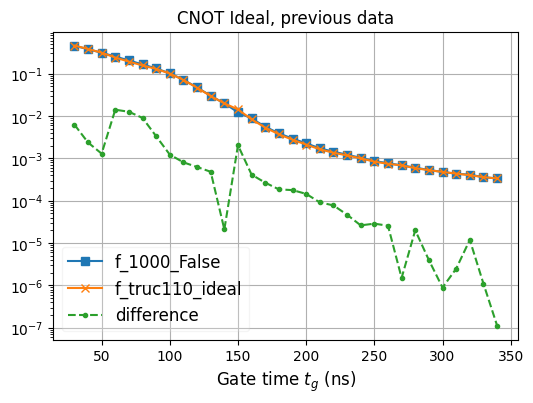

In [9]:
fig, ax = plt.subplots(figsize=(6,4))
ax.plot(cnot['tg'], 10**cnot['f_1000_False'], 's-',  label=r'f_1000_False')
# ax.plot(cnot['tg'], 10**cnot['f_200_select'], 'x-',  label=r'f_200_select')
# ax.plot(cnot['tg'], np.abs(10**cnot['f_200_select'] - 10**cnot['f_1000_False']), '.--',  label=r'difference')

ax.plot(cnot['tg'], 10**cnot['f_truc110_ideal'], 'x-',  label=r'f_truc110_ideal')
ax.plot(cnot['tg'], np.abs(10**cnot['f_truc110_ideal'] - 10**cnot['f_1000_False']), '.--',  label=r'difference')

plt.yscale('log')
plt.xlabel('Gate time $t_g$ (ns)', fontsize=12)
plt.title(r'CNOT Ideal, previous data', fontsize=12)
plt.grid()
legend = plt.legend(loc='lower left', fontsize=12)
legend.get_frame().set_alpha(0.2)  # 0.5 makes the legend 50% transparent

### Infidelity convergence vs truncation

max_step=1e-3

In [16]:
f_ideal_100_1e3 = np.array([
-0.5608349753564063, -1.3975658834782951, -2.0665457484027208, -2.3235814871678384 ,
-2.535586441845595 ,
])
f_ideal_200_1e3 = np.array([
-0.5737523722918979, -1.4005184860845281, -2.112585440077793, -2.384846244500785 ,
-2.5973475824446344 ,
])
f_ideal_300_1e3 = np.array([
-0.5324359705702385, -1.3502950956175817, -2.5325404418610877, -3.1216704182570187 ,
-3.4526069327265807 ,
])
f_ideal_500_1e3 = np.array([
-0.49865589914762887, -1.314653543012705, -2.5215878831378236, -3.12079239264896 ,
-3.451329268792737 ,
])
f_ideal_1000_1e3 = np.array([
-0.48115027339792227, -1.282133780694707, -2.048601144284009, -2.8133466065899952 ,
-3.4029655386915025 ,
])
truc = [100, 200, 300, 500, 1000]
f_ideal_1e3 = np.column_stack((f_ideal_100_1e3, f_ideal_200_1e3, f_ideal_300_1e3,
                               f_ideal_500_1e3, f_ideal_1000_1e3 ))

In [25]:

truc_true = np.arange(50, 1001, 50).tolist()

f_true = np.array([
[-0.26429282, -0.43713196, -0.33346741, -0.40395186, -0.56406677],
[-0.56083498, -1.39756588, -2.06654575, -2.32358149, -2.53558644],
[-0.68832975, -1.44331735, -2.07135286, -2.33649479, -2.54997386],
[-0.57375237, -1.40051849, -2.11258544, -2.38484624, -2.59734758],
[-0.52239618, -1.34613069, -2.52950154, -3.12089878, -3.45281184],
[-0.53243597, -1.3502951 , -2.53254044, -3.12167042, -3.45260693],
[-0.50358979, -1.35416318, -2.53820257, -3.12292448, -3.45276155],
[-0.48786732, -1.32156795, -2.52929222, -3.12182423, -3.45203114],
[-0.48556427, -1.31462711, -2.5213821 , -3.12120482, -3.45169124],
[-0.4986559 , -1.31465354, -2.52158788, -3.12079239, -3.45132927],
[-0.49792592, -1.31151973, -2.5169221 , -3.12069758, -3.45125532],
[-0.50349002, -1.29723708, -2.4569114 , -3.12069797, -3.45104067],
[-0.50199364, -1.27034361, -2.0512982 , -2.79553216, -3.40809315],
[-0.50325194, -1.27166301, -2.0707022 , -2.80884293, -3.40613756],
[-0.50426364, -1.27323431, -2.07106566, -2.81420508, -3.4045628 ],
[-0.50466697, -1.27377939, -2.06128957, -2.82039293, -3.40273174],
[-0.50440723, -1.27430271, -2.05239012, -2.82339862, -3.40307723],
[-0.50434535, -1.27701143, -2.0548789 , -2.82042437, -3.4059963 ],
[-0.49376323, -1.27837803, -2.05513981, -2.81793046, -3.40613685],
[-0.48115027, -1.28213378, -2.04860114, -2.81334661, -3.40296554]
])

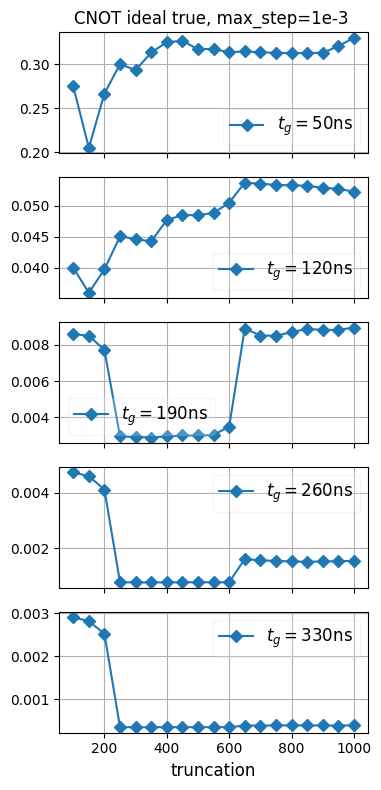

In [27]:
start = 1

fig, ax = plt.subplots(5, 1, figsize=(4, 8), sharex=True)
for i in range(5):
    ax[i].plot(truc_true[start:], 10**f_true[start:,i], 'D-', label=fr'$t_g = {tg_list[i]:.0f}$ns')
    # ax[i].set_xscale('log')
    ax[i].grid()
    legend = ax[i].legend(loc="best", fontsize=12)
    legend.get_frame().set_alpha(0.2)
    # ax[i].set_ylabel(fr'$t_g = {params[:,0][i]:.0f}$ns')
ax[4].set_xlabel('truncation', fontsize=12)
ax[0].set_title(fr'CNOT ideal true, max_step=1e-3 ', fontsize=12)
plt.tight_layout()

In [28]:
truc_true.index(600)

11

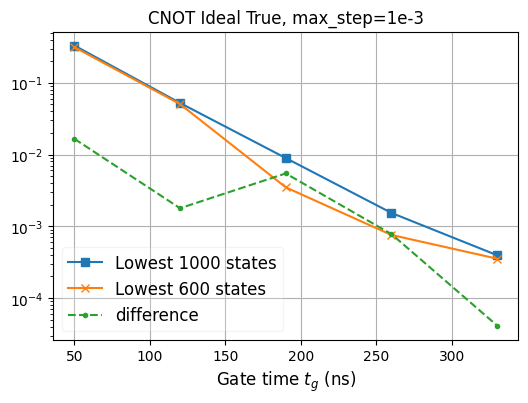

In [31]:
truc = 600
idx = truc_true.index(truc)

fig, ax = plt.subplots(figsize=(6,4))
ax.plot(tg_list, 10**f_true[-1], 's-',  label=r'Lowest 1000 states')
ax.plot(tg_list, 10**f_true[idx], 'x-',  label=f'Lowest {truc} states')
ax.plot(tg_list, np.abs(10**f_true[-1] - 10**f_true[idx]), '.--',  label=r'difference')

plt.yscale('log')
plt.xlabel('Gate time $t_g$ (ns)', fontsize=12)
plt.title(r'CNOT Ideal True, max_step=1e-3', fontsize=12)
plt.grid()
legend = plt.legend(loc='lower left', fontsize=12)
legend.get_frame().set_alpha(0.2)  # 0.5 makes the legend 50% transparent

### Infidelity convergence vs truncation

max_step=1e-4

In [5]:
f_ideal_100_1e4 = np.array([
-0.5608268241656571, -1.3975974586179958, -2.0669584313983314, -2.3244064658170123 ,
-2.536911070070739 ,
])
f_ideal_200_1e4 = np.array([
-0.5737844200138282, -1.4005908979955024, -2.112915635596642, -2.385424076939623 ,
-2.59821471736574 ,
])
f_ideal_300_1e4 = np.array([
-0.53243029381785, -1.350229396988937, -2.532427917610461, -3.1215461634732913 ,
-3.452428649040791 ,
])
f_ideal_500_1e4 = np.array([
-0.4987371586900626, -1.316002596185962, -2.522619428124679, -3.1212413553554574 ,
-3.451383764325859 ,
])
f_ideal_1000_1e4 = np.array([
-0.48107804711348917, -1.2818215524954497, -2.070093844633445, -2.8256327125399876 ,
-3.4156157874624506 ,
])
truc = [100, 200, 300, 500, 1000]
f_ideal_1e4 = np.column_stack((f_ideal_100_1e4, f_ideal_200_1e4, f_ideal_300_1e4,
                               f_ideal_500_1e4, f_ideal_1000_1e4 ))

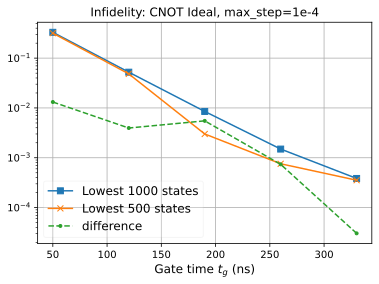

In [6]:
fig, ax = plt.subplots(figsize=(6,4))
ax.plot(tg_list, 10**f_ideal_1000_1e4, 's-',  label=r'Lowest 1000 states')
ax.plot(tg_list, 10**f_ideal_500_1e4, 'x-',  label=r'Lowest 500 states')
# ax.plot(tg_list, 10**f_ideal_110_3e4, 'x-',  label=r'max_step=3e-4')
ax.plot(tg_list, np.abs(10**f_ideal_1000_1e4 - 10**f_ideal_500_1e4), '.--',  
        label=r'difference')

plt.yscale('log')
plt.xlabel('Gate time $t_g$ (ns)', fontsize=12)
plt.title(r'Infidelity: CNOT Ideal, max_step=1e-4', fontsize=12)
plt.grid()
legend = plt.legend(loc='lower left', fontsize=12)
legend.get_frame().set_alpha(0.2)  # 0.5 makes the legend 50% transparent

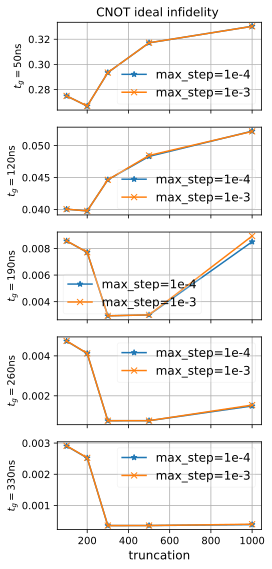

In [10]:
fig, ax = plt.subplots(5, 1, figsize=(4, 8), sharex=True)
for i in range(5):
    ax[i].plot(truc, 10**f_ideal_1e4[i], '*-', label=fr'max_step=1e-4')
    ax[i].plot(truc, 10**f_ideal_1e3[i], 'x-', label=fr'max_step=1e-3')
    # ax[i].set_xscale('log')
    ax[i].grid()
    legend = ax[i].legend(loc="best", fontsize=12)
    legend.get_frame().set_alpha(0.2)
    ax[i].set_ylabel(fr'$t_g = {tg_list[i]:.0f}$ns')
ax[4].set_xlabel('truncation', fontsize=12)
ax[0].set_title(fr'CNOT ideal infidelity ', fontsize=12)
plt.tight_layout()

### Infidelity convergence vs max_step

selected 110 states

In [ ]:
f_ideal_110_1e3 = np.array([
-0.5038292830031199, -1.3267637517474546, -2.5571541981405987, -3.1633836113782117 ,
-3.4805683672062053 ,
])
f_ideal_110_3e4 = np.array([
-0.5037842427356715, -1.3275235452899399, -2.560930477584596, -3.162944692125892 ,
-3.480454078048089 ,
])
f_ideal_110_1e4 = np.array([
-0.5037847247500232, -1.3275244861266038, -2.560914454378997, -3.1629302821063665 ,
-3.480482346346726 ,
])
f_ideal_110_3e5 = np.array([
-0.5037847181945132, -1.32750970283638, -2.560855063529726, -3.1628144010207557 ,
-3.480329379101597 ,
])
f_ideal_110_1e5 = np.array([
-0.5037838909702896, -1.32747855042218, -2.5608442416437165, -3.162872543112692 ,
-3.4804296613776535 ,
])

f_ideal_200 = np.column_stack((f_ideal_110_1e5, f_ideal_110_3e5, f_ideal_110_1e4, 
                               f_ideal_110_3e4, f_ideal_110_1e3 ))

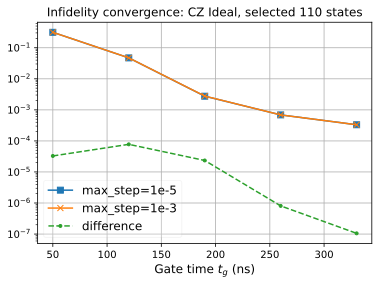

In [10]:
fig, ax = plt.subplots(figsize=(6,4))
ax.plot(tg_list, 10**f_ideal_110_1e5, 's-',  label=r'max_step=1e-5')
ax.plot(tg_list, 10**f_ideal_110_1e3, 'x-',  label=r'max_step=1e-3')
# ax.plot(tg_list, 10**f_ideal_110_3e4, 'x-',  label=r'max_step=3e-4')
ax.plot(tg_list, np.abs(10**f_ideal_110_1e5 - 10**f_ideal_110_1e3), '.--',  label=r'difference')

plt.yscale('log')
plt.xlabel('Gate time $t_g$ (ns)', fontsize=12)
plt.title(r'Infidelity convergence: CZ Ideal, selected 110 states', fontsize=12)
plt.grid()
legend = plt.legend(loc='lower left', fontsize=12)
legend.get_frame().set_alpha(0.2)  # 0.5 makes the legend 50% transparent

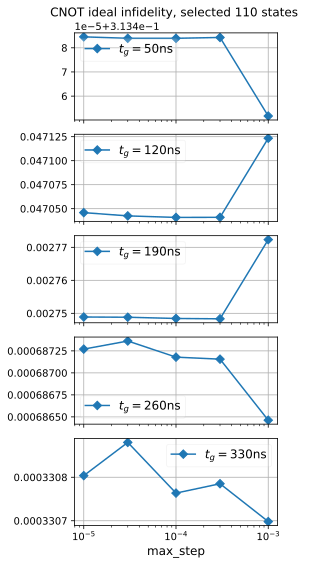

In [11]:
fig, ax = plt.subplots(5, 1, figsize=(4, 8), sharex=True)
for i in range(5):
    ax[i].plot(msteps, 10**f_ideal_200[i], 'D-', label=fr'$t_g = {tg_list[i]:.0f}$ns')
    ax[i].set_xscale('log')
    ax[i].grid()
    legend = ax[i].legend(loc="best", fontsize=12)
    legend.get_frame().set_alpha(0.2)
    # ax[i].set_ylabel(fr'$t_g = {params[:,0][i]:.0f}$ns')
ax[4].set_xlabel('max_step', fontsize=12)
ax[0].set_title(fr'CNOT ideal infidelity, selected 110 states ', fontsize=12)
plt.tight_layout()

### get ratio between dephasing and decay

In [ ]:
# CZ,170us, truncation=40,
tg = [32,74,116,158,200]
f_ideal = [ -0.37162705, -1.35908602, -2.90767694, -3.59798188 , -3.95481693 , ]
f_decay = [ -0.37161628, -1.35892836, -2.90185895, -3.57113501 , -3.89801909 , ]
f_dephase = [ -0.37158271, -1.35821592, -2.85902110, -3.36419611 , -3.48048711 , ]
f_both = [ -0.37158805, -1.35813258, -2.85745975, -3.36192231 , -3.47917535 , ]
def ratio(f_dephase, f_decay):
    return round(10**(f_dephase) / 10**(f_decay), 2)
lst = [ratio(a,b) for a, b in zip(f_dephase, f_decay)]
print(lst)
print(' (1-F_dephase) / (1-F_decay), tg=55,116ns, truncation=78,40')
print(f'xgate_170μs = {10**(-3.896) / 10**(-4.244):.2f}') # xgate 170 us
print(f'xgate_3μs = {10**(-2.234) / 10**(-2.722):.2f}') # xgate 3 us
print(f'cz_170μs = {10**(-2.859) / 10**(-2.902):.2f}') # cz 170 us
print(f'cz_3μs = {10**(-2.121) / 10**(-2.738):.2f}') # cz 3 us

[1.0, 1.0, 1.1, 1.61, 2.62]
 (1-F_dephase) / (1-F_decay), tg=55,116ns, truncation=78,40
xgate_170μs = 2.23
xgate_3μs = 3.08
cz_170μs = 1.10
cz_3μs = 4.14


### get meadian amplitude and detune from pulse parameters

In [ ]:
print(np.mean(cnot['detune_1']), np.mean(cnot['detune_2']))
print(cnot['detune_1'].median(), cnot['detune_2'].median())
print(np.mean(cnot['drive_amp_1']), np.mean(cnot['drive_amp_2']))
print(cnot['drive_amp_1'].median(), cnot['drive_amp_2'].median())

-0.0092455 -0.0088359375
-0.006548 -0.006191
0.040890499999999996 0.0233651875
0.031868 0.020352500000000003


In [ ]:
=